# Mega Case Study

## Part 1 - SOM

### Importing the libraries

In [1]:
!pip install minisom

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for minisom: filename=minisom-2.3.5-py3-none-any.whl size=12133 sha256=c1bda5bcd2ae356768e693b0beabab3de2946c12887309ff99a872d1346ba4b6
  Stored in directory: c:\users\shahr\appdata\local\pip\cache\wheels\0f\8c\a4\5b7aa56fa6ef11d536d45da775bcc5a2a1c163ff0f8f11990b
Successfully built minisom


  DEPRECATION: Building 'minisom' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'minisom'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Importing the dataset

In [3]:
dataset = pd.read_csv('Credit_Card_Applications.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

### Feature Scaling

In [4]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0,1))
X = sc.fit_transform(X)

### Training the SOM

In [5]:
from minisom import MiniSom
som = MiniSom(x=10, y=10, input_len= 15, sigma= 1.0, learning_rate = 0.5)
som.random_weights_init(X)
som.train_random(data = X, num_iteration = 100)

### Visualizing the results

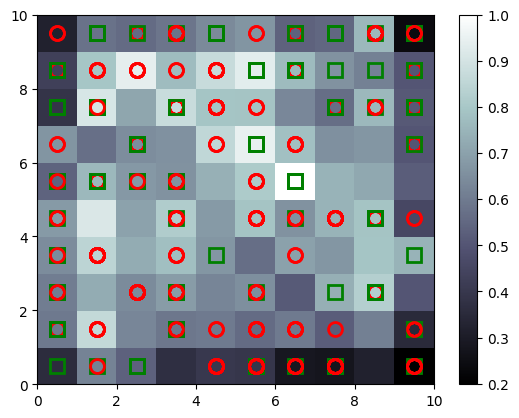

In [6]:
from pylab import bone, pcolor, colorbar, plot, show
bone()
pcolor(som.distance_map().T)
colorbar()
markers = ['o', 's']
colors = ['r', 'g']
for i, x in enumerate(X):
    w = som.winner(x)
    plot(w[0] + 0.5,
         w[1] + 0.5,
         markers[y[i]],
         markeredgecolor = colors[y[i]],
         markerfacecolor = 'None',
         markersize = 10,
         markeredgewidth = 2)
show()

### Finding the frauds

In [7]:
mappings = som.win_map(X)
frauds = np.concatenate((mappings[(6,8)], mappings[(5,1)]), axis = 0)
frauds = sc.inverse_transform(frauds)

### Printing the fraudulent clients

In [8]:
print('Fraud Customer IDs')
for i in frauds[:, 0]:
  print(int(i))

Fraud Customer IDs
15786237
15740487
15715907
15768342
15748532
15788634
15638272
15642001
15649101
15643574
15600027
15678779


## Part 2 - Going from Unsupervised to Supervised Deep Learning

### Creating the Matrix of Features

In [9]:
customers = dataset.iloc[:, 1:].values

### Creating the Dependent Variable

In [10]:
is_fraud = np.zeros(len(dataset))
for i in range(len(dataset)):
  if dataset.iloc[i,0] in frauds:
    is_fraud[i] = 1

## Part 3 - ANN

### Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
customers = sc.fit_transform(customers)

### Building the ANN

In [12]:
import tensorflow as tf
tf.__version__

'2.20.0'

In [13]:
ann = tf.keras.models.Sequential()
ann.add(tf.keras.layers.Dense(units=2, activation='relu'))
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

### Training the ANN

In [14]:
ann.fit(customers, is_fraud, batch_size = 1, epochs = 10)

Epoch 1/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9826 - loss: 0.2909
Epoch 2/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9826 - loss: 0.1496
Epoch 3/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 827us/step - accuracy: 0.9826 - loss: 0.1105
Epoch 4/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - accuracy: 0.9826 - loss: 0.0967
Epoch 5/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 837us/step - accuracy: 0.9826 - loss: 0.0888
Epoch 6/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 799us/step - accuracy: 0.9826 - loss: 0.0830
Epoch 7/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 809us/step - accuracy: 0.9826 - loss: 0.0782
Epoch 8/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 779us/step - accuracy: 0.9826 - loss: 0.0743
Epoch 9/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 789us/step - accuracy: 0.9826 - loss: 0.0712
Epoch 10/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 783us/step - accuracy: 0.9826 - loss: 0.0683


### Predicting the test set results

In [15]:
y_pred = ann.predict(customers)
y_pred = np.concatenate((dataset.iloc[:, 0:1].values, y_pred), axis = 1)
y_pred = y_pred[y_pred[:, 1].argsort()]

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [16]:
print(y_pred)

[[1.57997850e+07 1.70875808e-07]
 [1.56214230e+07 6.78373851e-07]
 [1.57238270e+07 1.34566812e-06]
 ...
 [1.56423360e+07 2.61913061e-01]
 [1.56710140e+07 2.61913061e-01]
 [1.57972460e+07 2.61913061e-01]]
